# BCIL Hackathon: Drug Prediction

Welcome to the **BCIL Hackathon!**

In this hackathon, we will explore computational approaches for **single-instance prediction tasks** using biomedical and chemical data. The goal is to use the provided datasets and tools to develop models that can identify promising drug combinations and ultimately improve our ability to predict therapeutic responses.

This notebook provides an introduction to the problem, the available data, and the tools that will be used throughout the hackathon. In particular, we will use the **Therapeutics Data Commons (TDC)** python framework to access and work with biomedical datasets.

### Hackathon Goals

By the end of the hackathon, you should be able to:

- Explore and preprocess drug data
- Represent drugs and biological systems using computational features
- Build a predictive model for drug combination efficacy
- Evaluate model performance
- Interpret and discuss the strengths and limitations of your approach

The emphasis is not necessarily on building the most sophisticated model, but on **developing a thoughtful computational approach, evaluating it carefully,** and **communicating what you learn from the data**.

Please create or load a python environment (Python 3.9-3.12). *Let's get started!*

## Blood-Brain Barrier Permeability Prediction (DEMO)

In [1]:
# # !git clone https://github.com/nurtilekgalimov/cleanmol.git
# %pip install -e ./cleanmol

In [2]:
# Necessary imports for this notebook

# The lines below are for installing the required packages in case they are not already installed. You can uncomment them if needed.
# import sys
# !{sys.executable} -m pip install numpy==1.26.4
# !{sys.executable} -m pip install PyTDC
# !{sys.executable} -m pip install "pandas>=2.1.4,<3.0.0"
# !{sys.executable} -m pip install "requests>=2.31.0,<3.0.0"
# !{sys.executable} -m pip install tqdm==4.70.0
# !{sys.executable} -m pip install "setuptools<82"
# !{sys.executable} -m pip install fuzzywuzzy
# !{sys.executable} -m pip install scikit-learn
# !{sys.executable} -m pip install huggingface_hub
# !{sys.executable} -m pip install matplotlib
# !{sys.executable} -m pip install rdkit
# !{sys.executable} -m pip install seaborn
# !{sys.executable} -m pip install torch
# !{sys.executable} -m pip install torch_geometric
# !{sys.executable} -m pip install selfies
# !{sys.executable} -m pip install -e git+https://github.com/nurtilekgalimov/cleanmol.git

from tdc.single_pred import ADME

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.decomposition import PCA

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Draw, AllChem, rdFingerprintGenerator
RDLogger.DisableLog("rdApp.warning")

import os
import tempfile
from cleanmol.cleanmol import CleanMolPipeline, PipelineConfig

import torch
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
import selfies as sf

import networkx as nx
from IPython.display import display

[22:22:32] Initializing Normalizer


## Data Exploration

[Therapeutics Data Commons (TDC)](https://tdcommons.ai/single_pred_tasks/overview/) organizes single-instance prediction problems; tasks that map *one* biomedical/chemical entity (e.g., a molecule) to a property or outcome. These are grouped into 8 task categories:

| Task | Description | Example Datasets |
|---|---|---|
| **ADME** | Absorption, Distribution, Metabolism, Excretion (pharmacokinetics) | Caco2_Wang, BBB_Martins, CYP3A4_Veith, Half_Life_Obach, Clearance_Microsome_AZ |
| **Tox** | Toxicity prediction | hERG, AMES, DILI, LD50_Zhu, ClinTox, Tox21, ToxCast |
| **HTS** | High-throughput screening hit prediction | HIV, SARSCoV2_3CLPro_Diamond, M1 Muscarinic Receptor Agonists/Antagonists |
| **QM** | Quantum mechanics property prediction | QM7b, QM8, QM9 |
| **Yields** | Reaction yield prediction | Buchwald-Hartwig, USPTO |
| **Epitope** | Epitope region prediction | IEDB_Jespersen, PDB_Jespersen |
| **Develop** | Antibody developability prediction | TAP, SAbDab_Chen |
| **CRISPROutcome** | CRISPR repair outcome prediction | Leenay |

Each dataset within these categories is accessible via the `PyTDC` package (`pip install PyTDC`), typically loaded as:

```python
from tdc.single_pred import ADME
data = ADME(name='BBB_Martins')
split = data.get_split()  # returns train/valid/test dicts
```

This introductory demo will use the **Blood-Brain Barrier (BBB)** dataset (BBB_Martins) to train and evaluate two separate models on predicting what molecules will successfully pass through the BBB. 

Permeating the BBB is historically a difficult challenge for medications that are intended to directly interact with the brain or a concern for medications that do permeate but unintentially produce negative effects. 

The two models being built and studied here are:
 - Logistic Regression (LR)
 - Graph Neural Network (GNN)

#### The BBB Data

In [3]:
# Get the BBB_Martins dataset and split it into training, validation, and test sets
data = ADME(name = 'BBB_Martins')
split = data.get_split()

# Check the keys of the split dictionary to see what splits are available
print("Keys in dataset split:", split.keys())

# Preview the first few rows of the training, validation, and test sets
print("\n########################### Training Set Preview ###########################")
print("Number of compunds that cross the BBB in the training set: ", (split['train']['Y'] == 1).sum())
print("Number of compunds that DO NOT cross the BBB in the training set: ", (split['train']['Y'] == 0).sum(),"\n")
train_df = split["train"].copy()
train_df.head()

Found local copy...
Loading...
Done!


Keys in dataset split: dict_keys(['train', 'valid', 'test'])

########################### Training Set Preview ###########################
Number of compunds that cross the BBB in the training set:  1096
Number of compunds that DO NOT cross the BBB in the training set:  325 



,Drug_ID,Drug,Y
0,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
1,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
2,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
3,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3C(C(=...,1
4,rolitetracycline,CN(C)[C@@H]1C(=O)/C(=C(/O)NCN2CCCC2)C(=O)[C@@]...,1


In [4]:
print("\n########################### Validation Set Preview ###########################")
print("Number of compunds that cross the BBB in the validation set: ", (split['valid']['Y'] == 1).sum())
print("Number of compunds that DO NOT cross the BBB in the validation set: ", (split['valid']['Y'] == 0).sum(),"\n")
valid_df = split["valid"].copy()
valid_df.head()


########################### Validation Set Preview ###########################
Number of compunds that cross the BBB in the validation set:  152
Number of compunds that DO NOT cross the BBB in the validation set:  51 



,Drug_ID,Drug,Y
0,timiperone,O=C(CCCN1CCC(n2c(=S)[nH]c3ccccc32)CC1)c1ccc(F)cc1,1
1,compound 32,O=[N+]([O-])C1=CC=NC1NCCSCc1ccccn1,1
2,ketorfanol,O=C1CC[C@H]2[C@H]3Cc4cccc(O)c4[C@@]2(CCN3CC2CC...,1
3,phenytoin,O=C1NC(=O)C(c2ccccc2)(c2ccccc2)N1,1
4,fluocortin,CCCCOC(=O)C(=O)C1C(C)CC2C3CC(F)C4=CC(=O)C=CC4(...,1


In [5]:
print("\n########################### Testing Set Preview ###########################")
print("Number of compunds that cross the BBB in the testing set: ", (split['test']['Y'] == 1).sum())
print("Number of compunds that DO NOT cross the BBB in the testing set: ", (split['test']['Y'] == 0).sum(),"\n")
test_df = split["test"].copy()
test_df.head()


########################### Testing Set Preview ###########################
Number of compunds that cross the BBB in the testing set:  303
Number of compunds that DO NOT cross the BBB in the testing set:  103 



,Drug_ID,Drug,Y
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1


As you can see from the previews, each observation (row) gives us three pieces of information, otherwise referred to as features (columns):
 1. Drug_ID:&emsp;    The name of the drug
 2. Drug:&emsp;&emsp;&ensp;       SMILES ID; text-based tags representing the 2D structure of molecules
 3. Y:&emsp;&emsp;&emsp;&emsp;&ensp;           Binary label stating either 1 (Yes) or 0 (No) for whether that molcules permeates the BBB

A common concern in ML/DL tasks is class imbalance. It is always helpful to explore the data first and foremost to try and identify this and similar issues prior to model development.

One particular measure of class imbalance that will be helpful later in interpreting the AUPRC (Area Under the Precision-Recall Curve) is Prevalence.

$$\text{Prevalence} = \frac{\text{Actual Positives}}{\text{Total Population}}=\frac P{P + N}$$

Prevalence (Train): 0.7712878254750176
Prevalence (Valid): 0.7487684729064039
Prevalence (Test): 0.7463054187192119


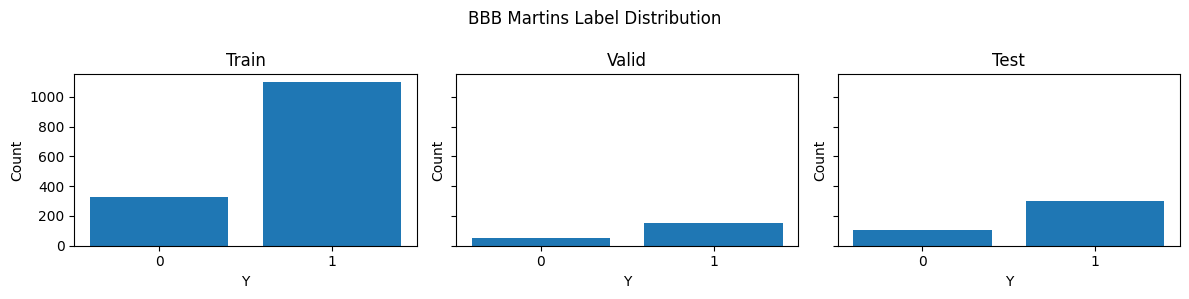

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, df, name in zip(
    axes,
    [train_df, valid_df, test_df],
    ["Train", "Valid", "Test"]
):
    counts = df["Y"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(name)
    ax.set_xlabel("Y")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0", "1"])

    print(f'Prevalence ({name}): {df["Y"].sum() / len(df["Y"])}')

# The last df was the test set. We are going to save the prevalence of the test set for later (related to the AUPRC)
prevalence_test = df["Y"].sum() / len(df["Y"])

plt.suptitle("BBB Martins Label Distribution")
plt.tight_layout()
plt.show()

The historgrams show that each split appears to have a majority class of molecules that pass the BBB. This may cause any model to perform worse on the minority class, molecules that do not pass the BBB. Many different techniques exist to combat this, such as **bootstrapping** where the minority class is over-sampled and/or the majority class is under-sampled.

Below is some 2D visualizations of the molecules we are training on beside their binary label.

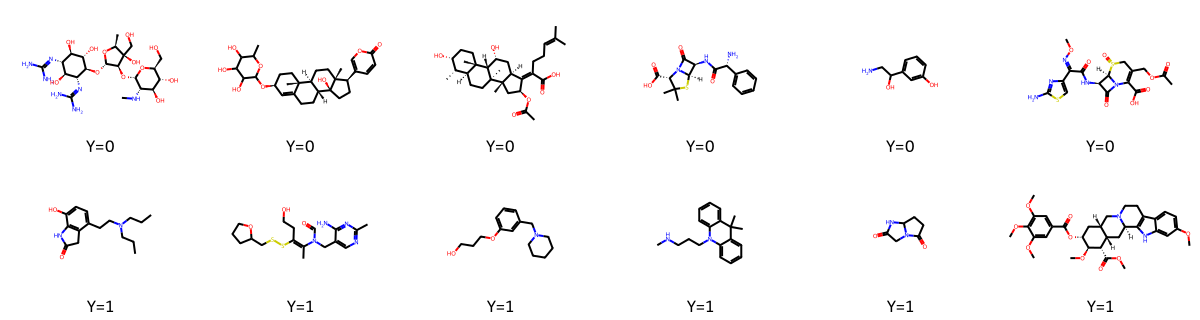

In [7]:
sample_df = (
    train_df.groupby("Y", group_keys=False)
      .apply(lambda g: g.sample(min(len(g), 6), random_state=42))
)

mols = [Chem.MolFromSmiles(smi) for smi in sample_df["Drug"]]
legends = [f"Y={y}" for y in sample_df["Y"]]

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=6,
        subImgSize=(200, 160),
        legends=legends
    )
)

## Logistic Regression Model
### Data Preprocessing: SMILES → Morgan fingerprints
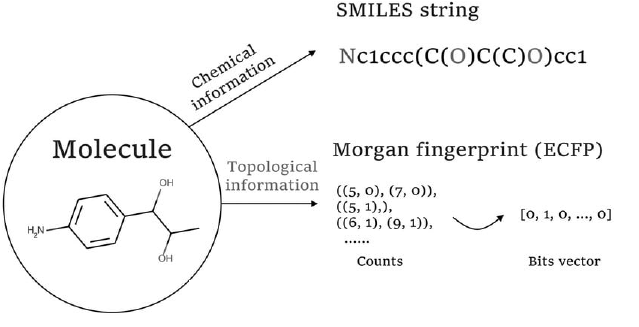

Molecular structures in TDC datasets are provided as **SMILES** (Simplified Molecular Input Line Entry System) strings, compact text representations of molecular graphs (atoms, bonds, rings, stereochemistry), as seen in the "Data" columns of the train/valid/test sets above. Before these can be used in most ML models, they need to be converted into fixed-length numerical vectors. Here we use **Morgan fingerprints** (a.k.a. circular fingerprints, the RDKit implementation of the ECFP algorithm).

**Pipeline steps:**

1. **Parse SMILES → RDKit Mol object**
   Each SMILES string is parsed into an `rdkit.Chem.Mol` object, which encodes the molecular graph explicitly. Invalid/unparseable SMILES are flagged and dropped or logged.

2. **Sanitize / Standardize**
   Common cleanup steps: stripping salts, neutralizing charges, canonicalizing tautomers, and removing stereochemistry if not needed — ensures consistent fingerprinting across near-duplicate structures.

3. **Generate Morgan fingerprints**
   For each Mol object, RDKit's `MorganGenerator` computes a circular substructure fingerprint:
   - **Radius**: how many bonds out from each atom to consider (radius=2 ≈ ECFP4, radius=3 ≈ ECFP6)
   - **Bit length**: fingerprint is hashed into a fixed-size bit vector (commonly 1024 or 2048 bits)
   - Each bit indicates presence/absence of a particular circular substructure pattern

4. **Output: fixed-length binary feature vector**
   Every molecule is now represented as a `(1, n_bits)` binary array, suitable as input to downstream ML models.

In [8]:
# Functions for this section: converting SMILES to Morgan fingerprints and preparing features for machine learning models
def clean_df(df: pd.DataFrame, smiles_col: str = "Drug") -> pd.DataFrame:
    '''
    Takes in a DataFrame, standardizes all SMILES strings at once using CleanMol.
    '''
    config = PipelineConfig(
        smiles_column=smiles_col,
        remove_salts=True,
        keep_largest_fragment=True,
        normalize=True,
        deduplicate=True,
        verbose=False
    )
    pipeline = CleanMolPipeline(config)
    with tempfile.NamedTemporaryFile(mode='w+', suffix='.csv', delete=False) as temp_file:
        df.to_csv(temp_file.name, index=False)
        temp_path = temp_file.name
    try:
        result = pipeline.run_from_csv(temp_path)
        cleaned_df = result.dataframe
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)
            
    return cleaned_df

def smiles_to_morgan_fp(smiles, fp_size=2048, radius=2):
    '''
    Takes in a SMILES string and returns its Morgan fingerprint as a numpy array.
    '''
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return np.zeros(fp_size, dtype=np.int8), False
    
    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((fp_size,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr, True

def dataframe_to_features(df):
    '''
    Takes in a df column populated with SMILES strings and returns features for machine learning models.
    '''
    fps = []
    valid_smiles = []

    df = clean_df(df)
    
    for smiles in df["Drug"]:
        fp, ok = smiles_to_morgan_fp(smiles)
        fps.append(fp)
        valid_smiles.append(ok)
    
    X = np.vstack(fps)
    y = df["Y"].astype(int).values
    
    return X, y, np.array(valid_smiles), df

In [9]:
# Create a Morgan fingerprint generator with the specified radius and fingerprint size
RAD=2
FP_SIZE = 2048

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=RAD, fpSize=FP_SIZE)

# Prepare features for each dataset
X_train, y_train, train_valid_smiles, train_valid_df = dataframe_to_features(train_df)
X_valid, y_valid, valid_valid_smiles, valid_valid_df = dataframe_to_features(valid_df)
X_test, y_test, test_valid_smiles, test_valid_df = dataframe_to_features(test_df)

# Look at the number of samples in each dataset and the number of invalid SMILES strings that were filtered out
print("\n                  Original number of samples in training set:", len(train_df))
print("                                            Shape of X_train:", X_train.shape)
print("            Number of SMILES converted to MP in training set:", train_valid_smiles.sum())
print("    Number of invalid SMILES in training set after Clean Mol:", len(train_df) - X_train.shape[0])

print("\n                Original number of samples in validation set:", len(valid_df))
print("                                            Shape of X_valid:", X_valid.shape)
print("                Number of  converted to MP in validation set:", valid_valid_smiles.sum())
print("  Number of invalid SMILES in validation set after Clean Mol:", len(valid_df) - X_valid.shape[0])

print("\n                   Original number of samples in testing set:", len(test_df))
print("                                             Shape of X_test:", X_test.shape)
print("             Number of SMILES converted to MP in testing set:", test_valid_smiles.sum())
print("     Number of invalid SMILES in testing set after Clean Mol:", len(test_df) - X_test.shape[0])


                  Original number of samples in training set: 1421
                                            Shape of X_train: (1396, 2048)
            Number of SMILES converted to MP in training set: 1396
    Number of invalid SMILES in training set after Clean Mol: 25

                Original number of samples in validation set: 203
                                            Shape of X_valid: (202, 2048)
                Number of  converted to MP in validation set: 202
  Number of invalid SMILES in validation set after Clean Mol: 1

                   Original number of samples in testing set: 406
                                             Shape of X_test: (404, 2048)
             Number of SMILES converted to MP in testing set: 404
     Number of invalid SMILES in testing set after Clean Mol: 2


### Building a Basic Linear Regression Model for Drug Feature Prediction

**Logistic Regression (LR)** models are used as classification tools. Given a set of features for a specific observation as input, predict the class that the given observation fits into. 
$$LR(X) \to \tilde{y}$$
We then compare the model's prediction of the class ($\tilde{y}$) to the ground truth label ($y$) provided by the BBB dataset to get the model's performance.

LR is particular useful for classification because it gets the final prediction using a particular form of the **sigmoid function**, a function that results in a value between zero and one regardless of how big or small the input is. The output value being between zero and one **easily translates into a probability** of that observation being assigned to some binary class, such as the one hear of either 'Yes' or 'No' for whether a molecules passes through the BBB.

LR has an important hyperparamter referred to as **$C$**. It controls the inverse of regularization strength, meaning practically that it is the opposite of the penalty amount for the coefficients becoming large. **If $C$ is large**, then the penalty is low allowing the model to assign large weights to features and to bend the curve tightly to the training data (possibly leading to overfitting). **If $C$ is small**, then the penalty is high forcing the model coefficients to stay near zero. This scenario results in a simpler decision boundary that might underfit in complicated tasks.

Important Notes:
 - LR assumes linear relationships between features
 - LR is fast, lightweight, and inherently interpretable, all leading to it being a great baseline model
 - Extreme outliers can significantly impact performance, so it is recommended that features are normalized or standardized before training

Here, we are not only building the LR model with `model.fit`, but we are also testing different $C$ values to try and find where the underfitting vs. overfitting occurs.

In [10]:
candidate_C_values = [0.000001, 0.000003, 0.00001, 0.00003, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

valid_results = []

for C in candidate_C_values:
    model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=0,
    ))
])
    
    model.fit(X_train, y_train)
    
    valid_probs = model.predict_proba(X_valid)[:, 1]
    valid_preds = (valid_probs >= 0.5).astype(int)
    
    result = {
        "C": C,
        "valid_roc_auc": roc_auc_score(y_valid, valid_probs),
        "valid_pr_auc": average_precision_score(y_valid, valid_probs),
        "valid_accuracy": accuracy_score(y_valid, valid_preds),
        "valid_balanced_accuracy": balanced_accuracy_score(y_valid, valid_preds),
        "valid_f1": f1_score(y_valid, valid_preds),
    }
    
    valid_results.append(result)

valid_results_df = pd.DataFrame(valid_results)
valid_results_df


,C,valid_roc_auc,valid_pr_auc,valid_accuracy,valid_balanced_accuracy,valid_f1
0,0.000001,0.918582,0.963132,0.846535,0.819439,0.894915
1,0.000003,0.918582,0.963119,0.846535,0.819439,0.894915
2,0.000010,0.920790,0.964440,0.851485,0.829243,0.897959
3,0.000030,0.923387,0.965949,0.861386,0.855343,0.903448
4,0.000100,0.927802,0.969095,0.856436,0.858525,0.898955
5,0.000300,0.930788,0.971033,0.846535,0.858395,0.890459
6,0.001000,0.924945,0.969045,0.846535,0.838917,0.892734
7,0.003000,0.920530,0.967476,0.856436,0.845540,0.900344
8,0.010000,0.906506,0.961330,0.851485,0.829243,0.897959
9,0.030000,0.894949,0.955555,0.846535,0.812946,0.895623


Take note that we aren't taking performance of the model on the training set. We are interested how the model performs on data that it *has not* seen yet, so we evaluate that version of the trained model on the validation set. 

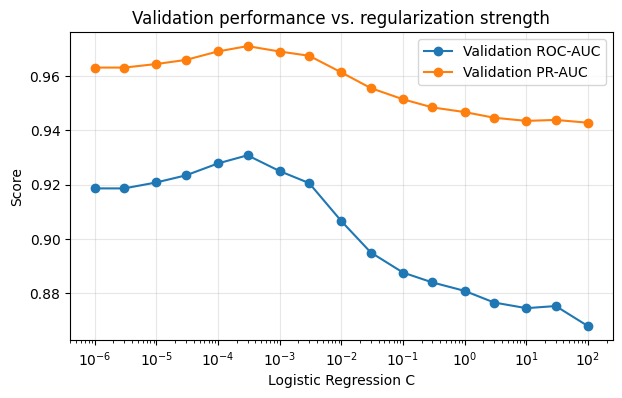

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(
    valid_results_df["C"],
    valid_results_df["valid_roc_auc"],
    marker="o",
    label="Validation ROC-AUC",
)

plt.plot(
    valid_results_df["C"],
    valid_results_df["valid_pr_auc"],
    marker="o",
    label="Validation PR-AUC",
)

plt.xscale("log")
plt.xlabel("Logistic Regression C")
plt.ylabel("Score")
plt.title("Validation performance vs. regularization strength")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
best_row = valid_results_df.sort_values("valid_roc_auc", ascending=False).iloc[0]
best_C = best_row["C"]

print("Best C:", best_C)
best_row

Best C: 0.0003


C                          0.000300
valid_roc_auc              0.930788
valid_pr_auc               0.971033
valid_accuracy             0.846535
valid_balanced_accuracy    0.858395
valid_f1                   0.890459
Name: 5, dtype: float64

In [13]:
X_train_valid = np.vstack([X_train, X_valid])
y_train_valid = np.concatenate([y_train, y_valid])

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=best_C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=0,
    ))
])

final_model.fit(X_train_valid, y_train_valid)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.0003


We found the besting fitting model using $C=0.03$. Let's set this as our final model and see how it performs on the test set. 

In practice, we would save the test set until the very end as a way to see how the best model we could get based on our validation data would do on entirely external new data out in the real world. There are better ways to do this, but this is a simple example to demonstrate.

In [14]:
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_probs),
    "PR-AUC": average_precision_score(y_test, test_probs),
    "Accuracy": accuracy_score(y_test, test_preds),
    "Balanced Accuracy": balanced_accuracy_score(y_test, test_preds),
    "Precision": precision_score(y_test, test_preds),
    "Recall": recall_score(y_test, test_preds),
    "F1": f1_score(y_test, test_preds),
}

pd.Series(test_metrics).to_frame("Test score")

,Test score
ROC-AUC,0.890236
PR-AUC,0.958288
Accuracy,0.824257
Balanced Accuracy,0.799036
Precision,0.907801
Recall,0.850498
F1,0.878216


Notice how we are thresholding at `test_probs >= 0.5`. This comes from interpreting the LR model's prediction literally as a classification probability. ROC-AUC and PR-AUC both test scenarios asking "What if the threshold wasn't at 0.5? What would the performance look like then?" This helps show not only how well the model performs (assuming balanced and imbalanced scenarios respectively) but also how robust the model is to altering that threshold value.

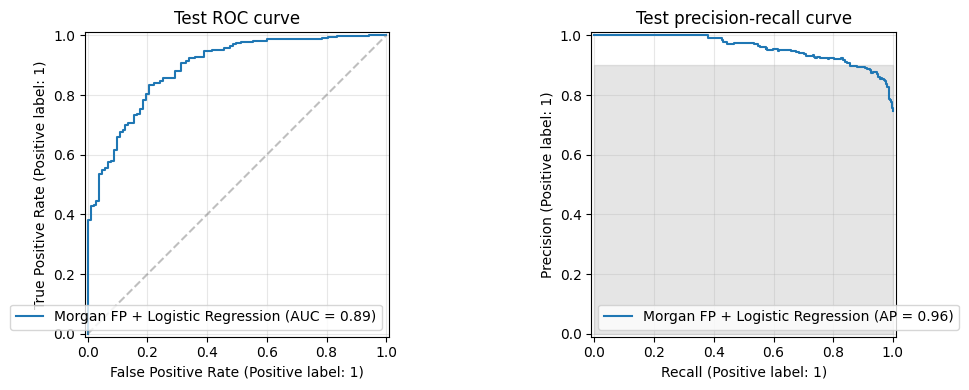

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(
    y_test,
    test_probs,
    ax=axes[0],
    name="Morgan FP + Logistic Regression",
)
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5, label='Random Chance Guessing')
axes[0].set_title("Test ROC curve")
axes[0].grid(True, alpha=0.3)

disp = PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probs,
    ax=axes[1],
    name="Morgan FP + Logistic Regression",
)
axes[1].set_title("Test precision-recall curve")
axes[1].grid(True, alpha=0.3)
plt.fill_between([0, 1], 0, 0.9, color="gray", alpha=0.2, label='Prevalence (area)')

plt.tight_layout()
plt.show()

Below is a confusion matrix, a helpful visualization for binary classification. The main diagonals are **True Negative (TN)** and **True Positive (TP)** whereas the off-diagonals are **False Positive (FP)** and **False Negative (FN)**. 

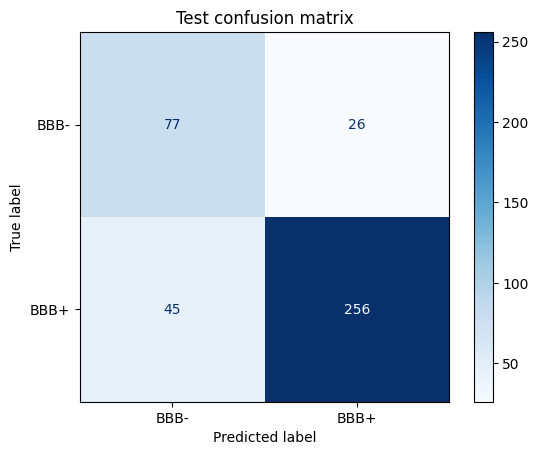

In [16]:
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BBB-", "BBB+"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Test confusion matrix")
plt.show()

We can now look at individual observation-specific predictions by updating the test data frame with the model prediction values.

In [17]:
test_predictions_df = test_valid_df.copy()
test_predictions_df["predicted_probability_BBB_positive"] = test_probs
test_predictions_df["predicted_label"] = test_preds
test_predictions_df["correct"] = test_predictions_df["Y"] == test_predictions_df["predicted_label"]

test_predictions_df.head()

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1,0.367006,0,False
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1,0.601743,1,True
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0,0.109981,0,True
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1,0.727013,1,True
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1,0.708514,1,True


Most confidently 'Yes' molecules predictions...

In [18]:
test_predictions_df.sort_values(
    "predicted_probability_BBB_positive",
    ascending=False
).head(10)[
    ["Drug_ID", "Drug", "Y", "predicted_probability_BBB_positive", "predicted_label", "correct"]
]

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
91,trifluoperazine,CN1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1,1,0.787429,1,True
268,iclazepam,O=C1CN=C(c2ccccc2)c2cc(Cl)ccc2N1CCOCC1CC1,1,0.775400,1,True
305,Nor-1-chlorpromazine,CNCCCN1c2ccccc2Sc2ccc(Cl)cc21,1,0.767852,1,True
137,fludiazepam,CN1C(=O)CN=C(c2ccccc2F)c2cc(Cl)ccc21,1,0.765914,1,True
172,thioproperazine,CN1CCN(CCCN2c3ccccc3Sc3ccc(S(=O)(=O)N(C)C)cc32...,1,0.765651,1,True
155,betamethasone-valerate,CCC(=O)OCC(=O)[C@@]1(OC(=O)CC)[C@@H](C)C[C@H]2...,1,0.765461,1,True
149,methopromazine,COc1ccc2c(c1)N(CCCN(C)C)c1ccccc1S2,1,0.759442,1,True
113,icometasone-enbutate,CCCC(=O)O[C@]1(C(=O)COC(C)=O)[C@H](C)C[C@H]2[C...,1,0.756506,1,True
140,flupimazine,OCCOC1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1,1,0.755598,1,True
13,1-hydroxymidazolam,OCc1ncc2n1-c1ccc(Cl)cc1C(c1ccccc1F)=NC2,1,0.755310,1,True


Most confidently 'No' molecules predictions...

In [19]:
test_predictions_df.sort_values(
    "predicted_probability_BBB_positive",
    ascending=True
).head(10)[
    ["Drug_ID", "Drug", "Y", "predicted_probability_BBB_positive", "predicted_label", "correct"]
]

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
281,cefuzonam,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(CSc3cn...,0,0.042154,0,True
355,cefatrizine,NC(C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(CSc3cn[nH]n...,0,0.052484,0,True
142,roxithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,0,0.059822,0,True
97,erythromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,0,0.066287,0,True
399,rifamide,CCN(CC)C(=O)COc1cc2c(O)c3c(O)c(C)c4c(c13)C(=O)...,0,0.070293,0,True
219,ceftiolene,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(/C=C/S...,0,0.073578,0,True
384,cefotaxime,CO/N=C(\C(=O)N[C@H]1C(=O)N2C(C(=O)O)=C(COC(C)=...,1,0.075138,0,False
62,flurithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,0,0.083884,0,True
41,ceftezole,O=C(Cn1cnnn1)N[C@@H]1C(=O)N2C(C(=O)O)=C(CSc3nn...,0,0.092636,0,True
293,arbekacin,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,0,0.095083,0,True


Most unsure molecule predictions...

In [20]:
test_predictions_df[
    (test_predictions_df['predicted_probability_BBB_positive'] <= 0.6) & 
    (test_predictions_df['predicted_probability_BBB_positive'] >= 0.4)].head(10)[
    ["Drug_ID", "Drug", "Y", "predicted_probability_BBB_positive", "predicted_label", "correct"]
]

,Drug_ID,Drug,Y,predicted_probability_BBB_positive,predicted_label,correct
6,fenmetramide,CC1NC(=O)COC1c1ccccc1,1,0.507358,1,True
8,bufenadrine,CN(C)CCOC(c1ccccc1)c1ccccc1C(C)(C)C,1,0.563883,1,True
9,napactadine,CN=C(Cc1ccc2ccccc2c1)NC,1,0.430995,0,False
10,dinazafone,C=C(C)CNCC(=O)N(C)c1ccc(Cl)cc1C(=O)c1ccccc1,1,0.581293,1,True
12,benactyzine,CCN(CC)CCOC(=O)C(O)(c1ccccc1)c1ccccc1,1,0.562442,1,True
17,nomifensine,CN1Cc2c(N)cccc2C(c2ccccc2)C1,1,0.570872,1,True
18,dexoxadrol(dioxadrolandlevoxadrol),c1ccc(C2(c3ccccc3)OC[C@H]([C@@H]3CCCCN3)O2)cc1,1,0.560936,1,True
19,tofenacin,CNCCOC(c1ccccc1)c1ccccc1C,1,0.573012,1,True
20,Delavirdine,CC(C)Nc1cccnc1N1CCN(C(=O)c2cc3cc(NS(C)(=O)=O)c...,0,0.494149,0,True
24,Methylprednisolone,C[C@H]1C[C@@H]2[C@H]([C@@H](O)C[C@@]3(C)[C@H]2...,0,0.596366,1,False


Distribution of predictions

In [21]:
test_predictions_df['predicted_probability_BBB_positive'].describe()

count    404.000000
mean       0.531522
std        0.171862
min        0.042154
25%        0.456775
50%        0.581675
75%        0.646381
max        0.787429
Name: predicted_probability_BBB_positive, dtype: float64

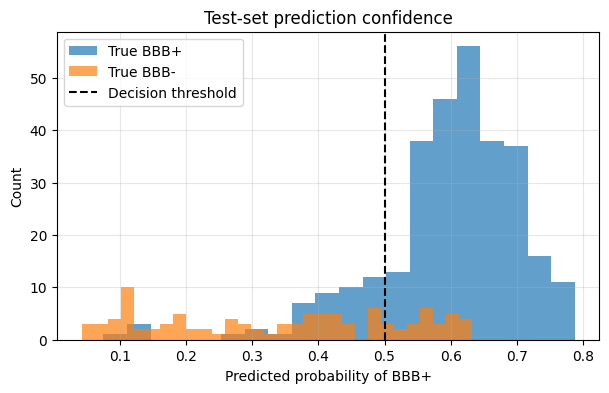

In [22]:
plt.figure(figsize=(7, 4))


plt.hist(
    test_predictions_df.loc[test_predictions_df["Y"] == 1, "predicted_probability_BBB_positive"],
    bins=20,
    alpha=0.7,
    label="True BBB+",
)

plt.hist(
    test_predictions_df.loc[test_predictions_df["Y"] == 0, "predicted_probability_BBB_positive"],
    bins=30,
    alpha=0.7,
    label="True BBB-",
)

plt.axvline(0.5, color="black", linestyle="--", label="Decision threshold")

plt.xlabel("Predicted probability of BBB+")
plt.ylabel("Count")
plt.title("Test-set prediction confidence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Since LR is inherently interpretable, we can investigate as to what contributed to a given decision, right?

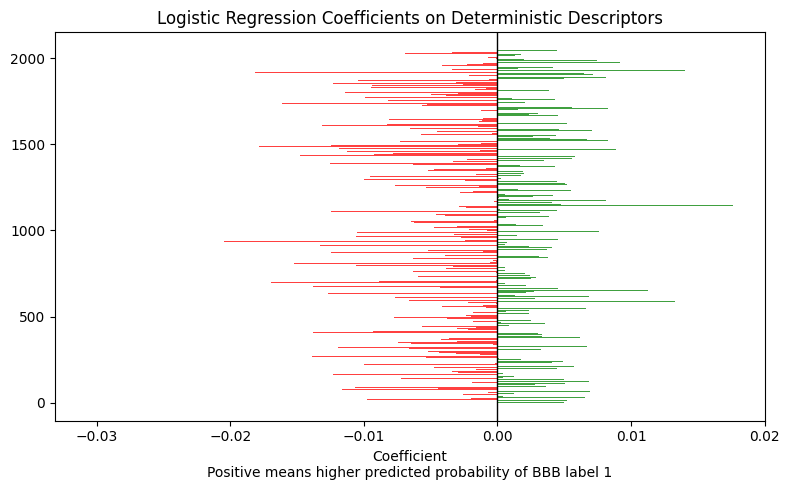

,Feature,Coefficient
5,5,-0.030706
456,456,-0.029812
807,807,-0.028617
673,673,-0.026346
233,233,-0.026219
...,...,...
165,165,0.013299
1199,1199,0.013574
1928,1928,0.014052
1480,1480,0.016304


In [23]:
logreg = final_model.named_steps["logreg"]

coef_df = pd.DataFrame({
    "Feature": list(range(len(X_train[0]))),
    "Coefficient": logreg.coef_[0]
}).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
colors = ["red" if c < 0 else "green" for c in coef_df["Coefficient"]]

plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, alpha=0.75)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients on Deterministic Descriptors")
plt.xlabel("Coefficient\nPositive means higher predicted probability of BBB label 1")
plt.tight_layout()
plt.show()

coef_df

Unfortunately, Morgan Fingerprint features aren't interpretable themself at face-value so, while we can see which elements of the fingerprint contributed the most, we would need to replace the fingerprint with human-understandable features to make use of the interpretability of the LR model.

In [24]:
# test_predictions_df.to_csv("bbb_martins_test_predictions.csv", index=False)
# print("Saved predictions to bbb_martins_test_predictions.csv")

## Graph Neural Network
### Data Preprocessing: SMILES → SELFIES → Molecular Graph
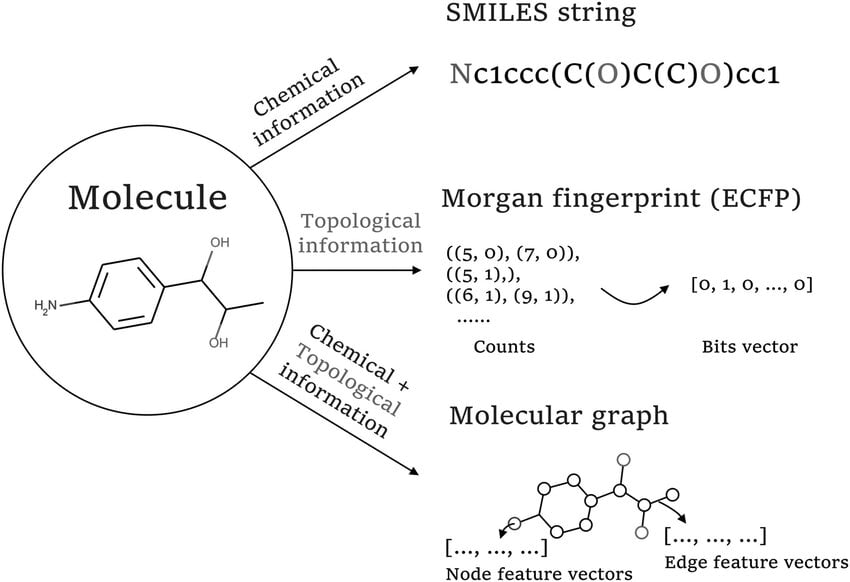

[What is GNN (structure)? why consider it with other methods like LR?]

[SMILES vs. SELFIES vs. Molecular Graph] 

In [25]:
def smiles_to_selfies_to_graph(smiles_string, y=None):
    try:
        selfies_string = sf.encoder(smiles_string)   # Convert SMILES to SELFIES
    except Exception as e:
        raise ValueError(f"SMILES conversion to SELFIES failed: {e}")
        
    mol_from_selfies = sf.decoder(selfies_string)    # Convert SELFIES to RDKit Molecule for graph extraction
    mol = Chem.MolFromSmiles(mol_from_selfies)
    
    if mol is None:
        raise ValueError("Invalid molecule generated from SELFIES.")

    node_features = []
    for atom in mol.GetAtoms():
        node_features.append([atom.GetAtomicNum(), atom.GetDegree()])    # Extract node (atom) features
    x = torch.tensor(node_features, dtype=torch.float)

    edge_indices = []
    for bond in mol.GetBonds():                                          # Extract edge (bond) indices
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices += [[i, j], [j, i]]  # Undirected graph
        
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)


In [26]:
ATOM_TYPES = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]  
#             H, C, N, O, F,  P,  S, Cl, Br,  I

DEGREES = [0, 1, 2, 3, 4, 5]


def one_hot_with_unknown(value, choices):
    """
    One-hot encode value.
    If value is not in choices, all zeros are used.
    """
    return [int(value == choice) for choice in choices]


def atom_features(atom):
    atomic_num = atom.GetAtomicNum()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()
    is_aromatic = int(atom.GetIsAromatic())

    features = []
    features += one_hot_with_unknown(atomic_num, ATOM_TYPES)
    features += one_hot_with_unknown(degree, DEGREES)
    features += [formal_charge]
    features += [is_aromatic]

    return features

def selfies_to_smiles_to_graph_v2(smiles, y=None):
    try:
        selfies_str = sf.encoder(smiles)                            # Convert SMILES to SELFIES string
    except Exception as e:
        print(f"SELFIES encoding failed for SMILES {smiles}: {e}")
        return None

    mol = Chem.MolFromSmiles(smiles)               # Generate RDKit molecule object for graph structure
    if mol is None:
        return None
        
    node_features = []
    for atom in mol.GetAtoms():
        node_features.append(atom_features(atom))    # Extract node features using your custom function
    x = torch.tensor(node_features, dtype=torch.float)
    
    edge_indices = []
    for bond in mol.GetBonds():                               # Extract edge indices (undirected bonds)
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices += [[i, j], [j, i]]
        
    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        
    data = Data(x=x, edge_index=edge_index)                   # Construct PyTorch Geometric Data object
    
    if y is not None:
        data.y = torch.tensor([float(y)], dtype=torch.float)             # Add target label if provided
        
    data.smiles = smiles                                   # Attach representations to the graph object
    data.selfies = selfies_str
    
    return data

# Setup data
def get_dataset_loader(df: pd.DataFrame):

    data_list = []
    valid_rows = []
    
    for _, row in df.iterrows():
        data = selfies_to_smiles_to_graph_v2(row["Drug"], row["Y"])
        if data is not None:
            data_list.append(data)
            valid_rows.append(row)
            
    # dataset = list(zip([smiles_to_selfies_to_graph(mol) for mol in df["Drug"]], list(torch.tensor(df["Y"].astype(int).values))))
    loader = DataLoader(data_list, batch_size=32, shuffle=True)

    return data_list, loader

train_dataset, train_loader = get_dataset_loader(train_valid_df)


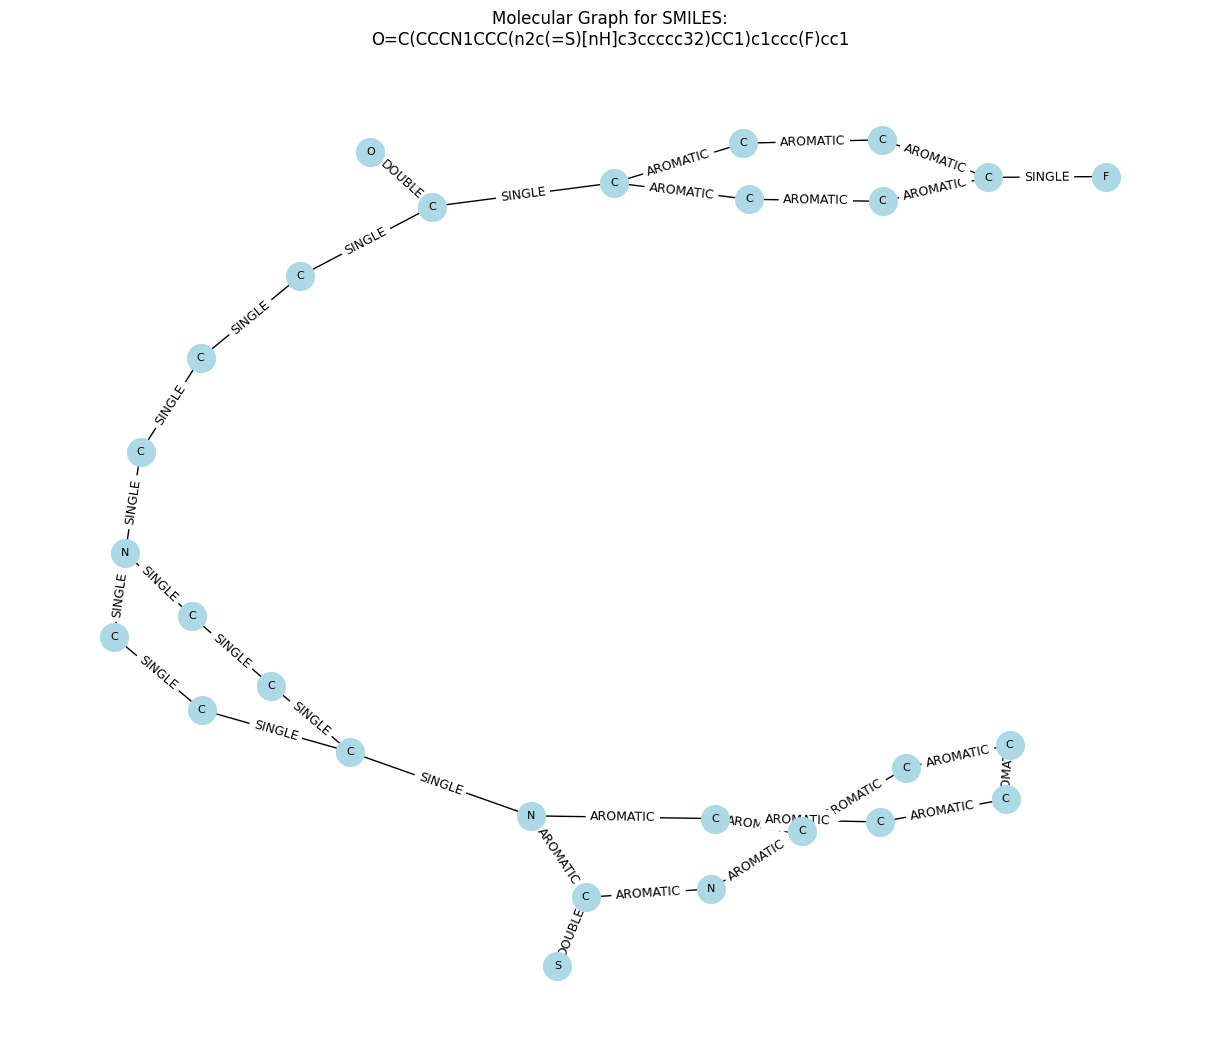

In [27]:
def plot_molecule_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    G = nx.Graph()

    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        label = atom.GetSymbol()
        G.add_node(idx, label=label)

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = str(bond.GetBondType())
        G.add_edge(i, j, label=bond_type)

    pos = nx.spring_layout(G, seed=42)

    node_labels = nx.get_node_attributes(G, "label")
    edge_labels = nx.get_edge_attributes(G, "label")

    plt.figure(figsize=(12, 10))
    nx.draw(
        G,
        pos,
        labels=node_labels,
        with_labels=True,
        node_size=400,
        node_color="lightblue",
        font_size=8
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title(f"Molecular Graph for SMILES:\n{smiles}")
    plt.axis("off")
    plt.show()


example_smiles = valid_df.iloc[0]["Drug"]
plot_molecule_graph(example_smiles)

In [28]:
val_dataset, val_loader = get_dataset_loader(valid_valid_df)
test_dataset, test_loader = get_dataset_loader(test_valid_df)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(val_dataset)}")

Train: 1396
Validation: 202
Test: 202


The Graph Neural Network (GNN) will consist of three convolutional layers, a mean pooling layer, and a classification section made up of linear projections, and the sigmoid function. 

In [29]:
class MolecularGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index, batch, return_embedding=False):
        # Message passing layer 1
        x = self.conv1(x, edge_index)
        x = F.tanh(x)
        x = self.dropout(x)

        # Message passing layer 2
        x = self.conv2(x, edge_index)
        x = F.tanh(x)
        x = self.dropout(x)

        # Message passing layer 3
        x = self.conv3(x, edge_index)
        x = F.tanh(x)
        x = self.dropout(x)

        # Pool atom embeddings into one molecule embedding
        graph_embedding = global_mean_pool(x, batch)
        clf_input = self.dropout(graph_embedding)

        # Predict BBB class
        logits = self.classifier(clf_input).squeeze(-1)

        if return_embedding:
            return logits, graph_embedding

        return logits

<!-- The loss function will be Mean Squared Error (MSE).

$$\text{MSE}(\tilde{y}, y)=\frac 1N \sum_{i=1}^N (y_i - \tilde{y}_i)^2$$ -->

The loss function will be Binary Cross Entropy (BCE).

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\sigma(x_i)) + (1 - y_i) \cdot \log(1 - \sigma(x_i)) \right]$$

$$\text{where }~\sigma(x_i) = \frac{1}{1 + e^{-x_i}}.$$

The optimizer will be Adam, an adaptive learning rate optimization function that has momentum when trying to find minima of the loss function.

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_node_features = train_dataset[0].x.shape[1]

model = MolecularGNN(
    num_node_features=num_node_features,
    hidden_dim=16,
    dropout=0.3
).to(device)

# Optional class imbalance handling
train_labels = [train_dataset[i].y for i in range(len(train_dataset))]
num_pos = sum(train_labels)
num_neg = len(train_labels) - num_pos

pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

In [31]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch#.to(device)

        optimizer.zero_grad()

        logits = model(batch.x, batch.edge_index, batch.batch)
        y = batch.y.view(-1)

        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_gnn(model, loader, criterion=None):
    model.eval()

    all_logits = []
    all_probs = []
    all_y = []
    all_embeddings = []

    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        logits, embeddings = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            return_embedding=True
        )

        y = batch.y.view(-1)

        if criterion is not None:
            loss = criterion(logits, y)
            total_loss += loss.item() * batch.num_graphs

        probs = torch.sigmoid(logits)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_y.append(y.cpu())
        all_embeddings.append(embeddings.cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_y = torch.cat(all_y).numpy()
    all_embeddings = torch.cat(all_embeddings).numpy()

    metrics = {}

    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    preds = (all_probs >= 0.5).astype(int)

    metrics["accuracy"] = accuracy_score(all_y, preds)

    if len(np.unique(all_y)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_y, all_probs)
        metrics["average_precision"] = average_precision_score(all_y, all_probs)
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return {
        "y": all_y,
        "probs": all_probs,
        "preds": preds,
        "embeddings": all_embeddings,
        "metrics": metrics
    }

In [32]:
history = []

num_epochs = 500

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_results = evaluate_gnn(model, val_loader, criterion)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_results["metrics"]["loss"],
        "val_accuracy": val_results["metrics"]["accuracy"],
        "val_roc_auc": val_results["metrics"]["roc_auc"],
        "val_average_precision": val_results["metrics"]["average_precision"]
    }

    history.append(row)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} | "
            f"Val ROC-AUC: {row['val_roc_auc']:.4f}"
        )

history_df = pd.DataFrame(history)


Epoch 010 | Train Loss: 0.2710 | Val Loss: 0.2605 | Val ROC-AUC: 0.8087
Epoch 020 | Train Loss: 0.2591 | Val Loss: 0.2402 | Val ROC-AUC: 0.8215
Epoch 030 | Train Loss: 0.2541 | Val Loss: 0.2369 | Val ROC-AUC: 0.8187
Epoch 040 | Train Loss: 0.2541 | Val Loss: 0.2353 | Val ROC-AUC: 0.8122
Epoch 050 | Train Loss: 0.2448 | Val Loss: 0.2350 | Val ROC-AUC: 0.8103
Epoch 060 | Train Loss: 0.2475 | Val Loss: 0.2348 | Val ROC-AUC: 0.8102
Epoch 070 | Train Loss: 0.2450 | Val Loss: 0.2339 | Val ROC-AUC: 0.8113
Epoch 080 | Train Loss: 0.2471 | Val Loss: 0.2340 | Val ROC-AUC: 0.8095
Epoch 090 | Train Loss: 0.2422 | Val Loss: 0.2332 | Val ROC-AUC: 0.8109
Epoch 100 | Train Loss: 0.2456 | Val Loss: 0.2305 | Val ROC-AUC: 0.8115
Epoch 110 | Train Loss: 0.2447 | Val Loss: 0.2306 | Val ROC-AUC: 0.8170
Epoch 120 | Train Loss: 0.2440 | Val Loss: 0.2294 | Val ROC-AUC: 0.8200
Epoch 130 | Train Loss: 0.2406 | Val Loss: 0.2276 | Val ROC-AUC: 0.8179
Epoch 140 | Train Loss: 0.2409 | Val Loss: 0.2270 | Val ROC-AUC:

It is good practice to review the loss and performance between the training set and validation set when developing neural networks as a way to keep an eye on overfitting. 

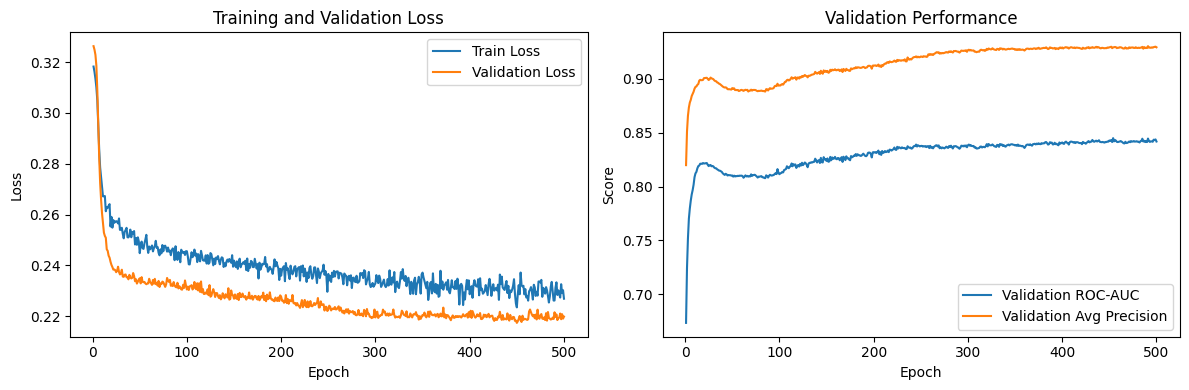

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], label="Validation ROC-AUC")
axes[1].plot(history_df["epoch"], history_df["val_average_precision"], label="Validation Avg Precision")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Performance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
gnn_test_results = evaluate_gnn(model, test_loader, criterion)

gnn_test_y = gnn_test_results["y"]
gnn_test_probs = gnn_test_results["probs"]
gnn_test_preds = gnn_test_results["preds"]

print("GNN Test Metrics")
for k, v in gnn_test_results["metrics"].items():
    print(f"{k}: {v:.3f}")

GNN Test Metrics
loss: 0.248
accuracy: 0.824
roc_auc: 0.832
average_precision: 0.922


There also might be some insightful discoveries by investigating the embeddings that the GNN formed its classification decision off of. This embedding is in high-dimensional space, so we use a dimensionality reduction technique to visualize it.

  ---==== Legend ====---
X    -  Incorrectly labeled
O    -  Correctly labeled

Blue -  Positive Class
Red  -  Correctly labeled
  ---================---


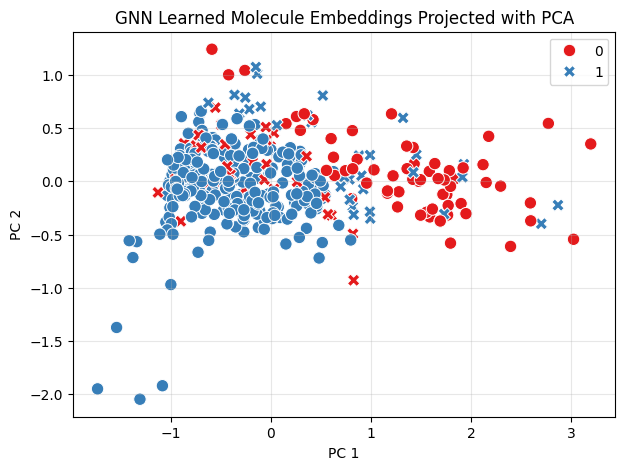

In [36]:
test_embeddings = gnn_test_results["embeddings"]
# test_labels = gnn_test_results["y"].astype(int)
# test_probs = gnn_test_results["probs"]
test_incorrect = gnn_test_results["preds"] != gnn_test_y

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(test_embeddings)

print("  ---==== Legend ====---")
print(f"X    -  Incorrectly labeled\nO    -  Correctly labeled\n")
print(f"Blue -  Positive Class\nRed  -  Correctly labeled")
print("  ---================---")

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=gnn_test_y.astype(int),
    style=test_incorrect,
    palette="Set1",
    s=80
)

plt.title("GNN Learned Molecule Embeddings Projected with PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
# plt.legend(title="BBB Label / Correct?")
plt.grid(alpha=0.3)
plt.show()

## Comparing LR to GNN

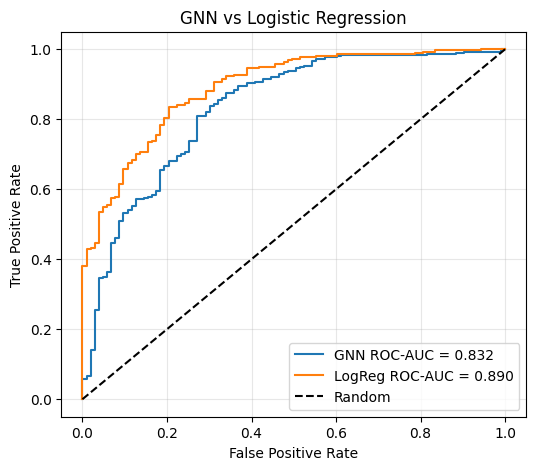

In [37]:
gnn_fpr, gnn_tpr, _ = roc_curve(gnn_test_y, gnn_test_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, test_probs)

gnn_auc = roc_auc_score(gnn_test_y, gnn_test_probs)
lr_auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(6, 5))

plt.plot(gnn_fpr, gnn_tpr, label=f"GNN ROC-AUC = {gnn_auc:.3f}")
plt.plot(lr_fpr, lr_tpr, label=f"LogReg ROC-AUC = {lr_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GNN vs Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

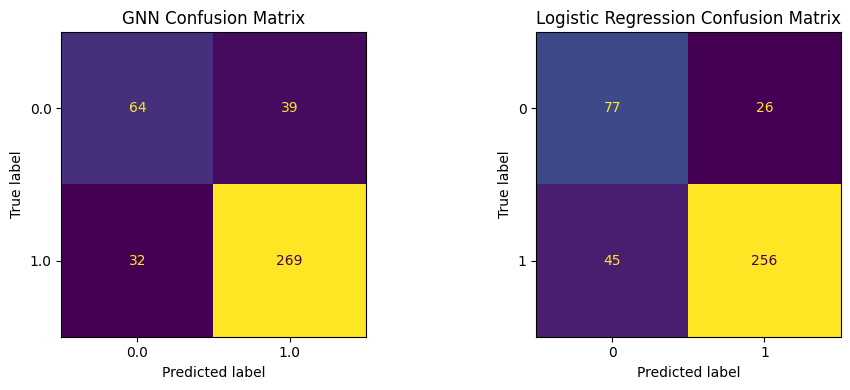

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    gnn_test_y,
    gnn_test_preds,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("GNN Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

## Potential Next Step: Add in Descriptive Molecule Features

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Lipinski, Crippen, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

import networkx as nx

Row index: 0
SMILES: CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](CC[C@@H]3C[C@@H](O)CC(=O)O3)[C@H]21
BBB label Y: 1


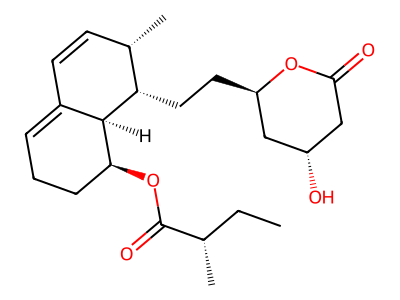

In [40]:
# Pick one molecule to inspect
# Try changing this number!
mol_index = 0

smiles = df.iloc[mol_index]["Drug"]
label = int(df.iloc[mol_index]["Y"])

mol = Chem.MolFromSmiles(smiles)

print(f"Row index: {mol_index}")
print(f"SMILES: {smiles}")
print(f"BBB label Y: {label}")

display(Draw.MolToImage(mol, size=(400, 300)))

In [41]:
def calculate_molecule_features(smiles):
    """
    Calculate deterministic, human-readable molecular descriptors.
    These are useful for explaining what chemists and simpler ML models might use.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    features = {
        "Molecular Weight": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "H-Bond Donors": Lipinski.NumHDonors(mol),
        "H-Bond Acceptors": Lipinski.NumHAcceptors(mol),
        "Rotatable Bonds": Lipinski.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "Aromatic Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Heavy Atoms": mol.GetNumHeavyAtoms(),
        "Heteroatoms": rdMolDescriptors.CalcNumHeteroatoms(mol),
        "Formal Charge": Chem.GetFormalCharge(mol),
        "Fraction Csp3": rdMolDescriptors.CalcFractionCSP3(mol),
    }
    
    return features


features = calculate_molecule_features(smiles)

feature_df = pd.DataFrame(
    features.items(),
    columns=["Feature", "Value"]
)

feature_df

,Feature,Value
0,Molecular Weight,390.52000
1,LogP,3.94950
2,TPSA,72.83000
3,H-Bond Donors,1.00000
4,H-Bond Acceptors,5.00000
5,Rotatable Bonds,6.00000
6,Rings,3.00000
7,Aromatic Rings,0.00000
8,Heavy Atoms,28.00000
9,Heteroatoms,5.00000


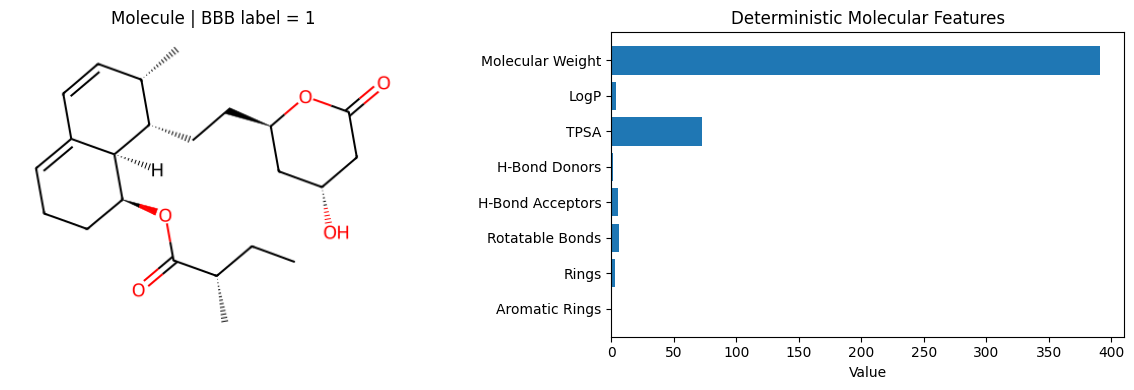

In [42]:
def molecule_card(smiles, label=None):
    mol = Chem.MolFromSmiles(smiles)
    features = calculate_molecule_features(smiles)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: molecule image
    img = Draw.MolToImage(mol, size=(400, 300))
    axes[0].imshow(img)
    axes[0].axis("off")
    
    title = "Molecule"
    if label is not None:
        title += f" | BBB label = {label}"
    axes[0].set_title(title)
    
    # Right: selected key descriptors
    key_features = [
        "Molecular Weight",
        "LogP",
        "TPSA",
        "H-Bond Donors",
        "H-Bond Acceptors",
        "Rotatable Bonds",
        "Rings",
        "Aromatic Rings"
    ]
    
    values = [features[k] for k in key_features]
    
    axes[1].barh(key_features, values)
    axes[1].invert_yaxis()
    axes[1].set_title("Deterministic Molecular Features")
    axes[1].set_xlabel("Value")
    
    plt.tight_layout()
    plt.show()


molecule_card(smiles, label)

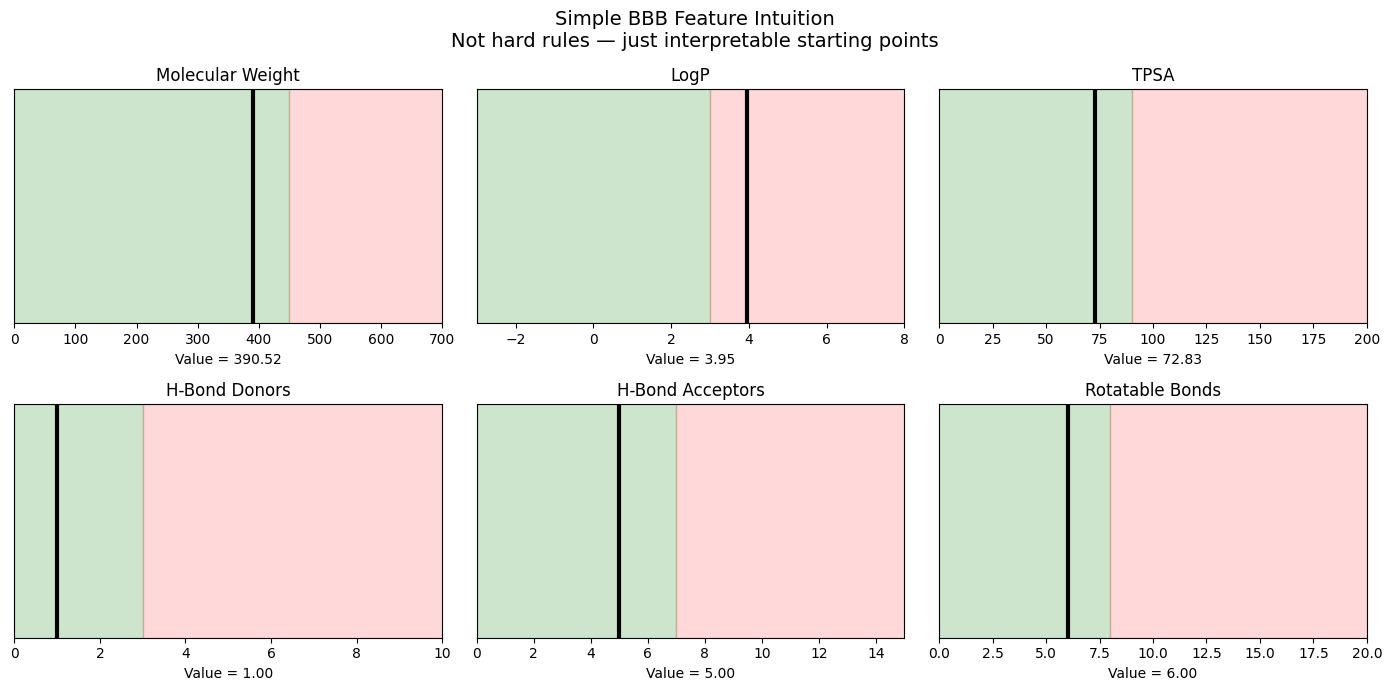

,Feature,Value,Common BBB-friendly intuition
0,Molecular Weight,390.5200,Often lower is easier
1,LogP,3.9495,Moderate lipophilicity often helps
2,TPSA,72.8300,Lower polar surface area often helps
3,H-Bond Donors,1.0000,Fewer donors often helps
4,H-Bond Acceptors,5.0000,Fewer acceptors often helps
5,Rotatable Bonds,6.0000,Fewer flexible bonds often helps


In [43]:
def plot_bbb_feature_guide(smiles):
    features = calculate_molecule_features(smiles)
    
    guide = pd.DataFrame({
        "Feature": [
            "Molecular Weight",
            "LogP",
            "TPSA",
            "H-Bond Donors",
            "H-Bond Acceptors",
            "Rotatable Bonds"
        ],
        "Value": [
            features["Molecular Weight"],
            features["LogP"],
            features["TPSA"],
            features["H-Bond Donors"],
            features["H-Bond Acceptors"],
            features["Rotatable Bonds"]
        ],
        "Common BBB-friendly intuition": [
            "Often lower is easier",
            "Moderate lipophilicity often helps",
            "Lower polar surface area often helps",
            "Fewer donors often helps",
            "Fewer acceptors often helps",
            "Fewer flexible bonds often helps"
        ]
    })
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()
    
    ranges = {
        "Molecular Weight": (0, 700, 450),
        "LogP": (-3, 8, 3),
        "TPSA": (0, 200, 90),
        "H-Bond Donors": (0, 10, 3),
        "H-Bond Acceptors": (0, 15, 7),
        "Rotatable Bonds": (0, 20, 8)
    }
    
    for ax, row in zip(axes, guide.itertuples()):
        feature = row.Feature
        value = row.Value
        xmin, xmax, threshold = ranges[feature]
        
        ax.axvspan(xmin, threshold, alpha=0.2, color="green", label="Often favorable")
        ax.axvspan(threshold, xmax, alpha=0.15, color="red", label="Often less favorable")
        ax.axvline(value, color="black", linewidth=3)
        
        ax.set_xlim(xmin, xmax)
        ax.set_yticks([])
        ax.set_title(feature)
        ax.set_xlabel(f"Value = {value:.2f}")
    
    plt.suptitle("Simple BBB Feature Intuition\nNot hard rules — just interpretable starting points", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return guide


bbb_guide_df = plot_bbb_feature_guide(smiles)
bbb_guide_df

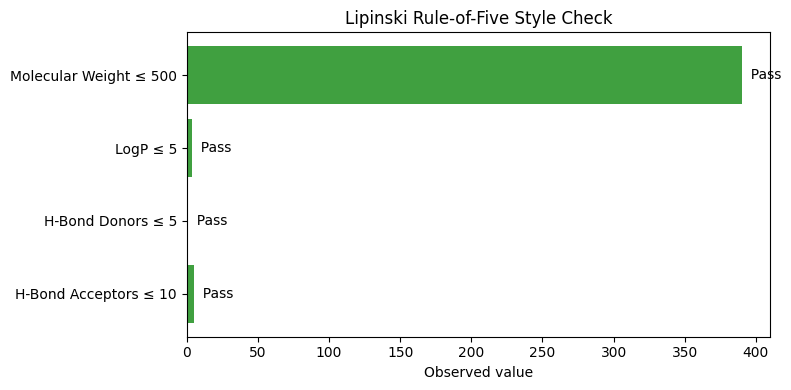

,Rule,Value,Pass
0,Molecular Weight ≤ 500,390.5200,True
1,LogP ≤ 5,3.9495,True
2,H-Bond Donors ≤ 5,1.0000,True
3,H-Bond Acceptors ≤ 10,5.0000,True


In [44]:
def lipinski_visual(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    
    rules = pd.DataFrame({
        "Rule": [
            "Molecular Weight ≤ 500",
            "LogP ≤ 5",
            "H-Bond Donors ≤ 5",
            "H-Bond Acceptors ≤ 10"
        ],
        "Value": [mw, logp, hbd, hba],
        "Pass": [
            mw <= 500,
            logp <= 5,
            hbd <= 5,
            hba <= 10
        ]
    })
    
    colors = ["green" if x else "red" for x in rules["Pass"]]
    
    plt.figure(figsize=(8, 4))
    plt.barh(rules["Rule"], rules["Value"], color=colors, alpha=0.75)
    plt.xlabel("Observed value")
    plt.title("Lipinski Rule-of-Five Style Check")
    plt.gca().invert_yaxis()
    
    for i, row in rules.iterrows():
        status = "Pass" if row["Pass"] else "Fail"
        plt.text(row["Value"], i, f"  {status}", va="center")
    
    plt.tight_layout()
    plt.show()
    
    return rules


lipinski_visual(smiles)

In [45]:
def atom_feature_table(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    rows = []
    for atom in mol.GetAtoms():
        rows.append({
            "Atom Index": atom.GetIdx(),
            "Element": atom.GetSymbol(),
            "Atomic Number": atom.GetAtomicNum(),
            "Degree": atom.GetDegree(),
            "Total Hydrogens": atom.GetTotalNumHs(),
            "Formal Charge": atom.GetFormalCharge(),
            "Hybridization": str(atom.GetHybridization()),
            "Is Aromatic": atom.GetIsAromatic(),
            "Is In Ring": atom.IsInRing(),
            "Mass": atom.GetMass()
        })
    
    return pd.DataFrame(rows)


atom_df = atom_feature_table(smiles)
atom_df

,Atom Index,Element,Atomic Number,Degree,Total Hydrogens,Formal Charge,Hybridization,Is Aromatic,Is In Ring,Mass
0,0,C,6,1,3,0,SP3,False,False,12.011
1,1,C,6,2,2,0,SP3,False,False,12.011
2,2,C,6,3,1,0,SP3,False,False,12.011
3,3,C,6,1,3,0,SP3,False,False,12.011
4,4,C,6,3,0,0,SP2,False,False,12.011
5,5,O,8,1,0,0,SP2,False,False,15.999
6,6,O,8,2,0,0,SP2,False,False,15.999
7,7,C,6,3,1,0,SP3,False,True,12.011
8,8,C,6,2,2,0,SP3,False,True,12.011
9,9,C,6,2,2,0,SP3,False,True,12.011


Highlight type: heteroatoms
Highlighted atom indices: [5, 6, 22, 25, 26]


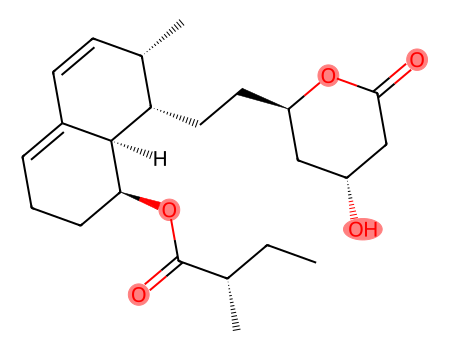

Highlight type: aromatic
Highlighted atom indices: []


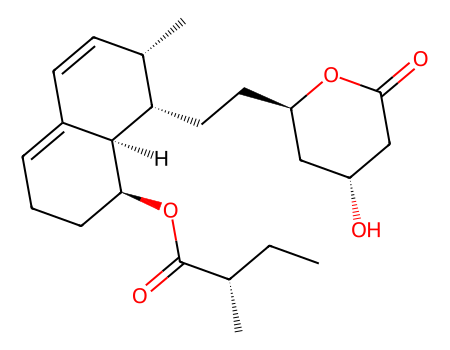

Highlight type: ring
Highlighted atom indices: [7, 8, 9, 10, 11, 12, 13, 14, 16, 19, 20, 21, 23, 24, 26, 27]


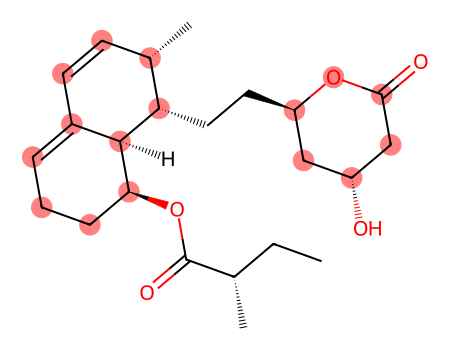

Highlight type: charged
Highlighted atom indices: []


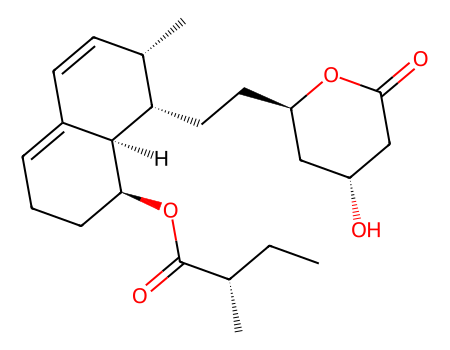

In [46]:
def draw_highlighted_atoms(smiles, highlight_type="heteroatoms"):
    mol = Chem.MolFromSmiles(smiles)
    
    highlight_atoms = []
    
    for atom in mol.GetAtoms():
        if highlight_type == "heteroatoms":
            if atom.GetAtomicNum() not in [1, 6]:
                highlight_atoms.append(atom.GetIdx())
        
        elif highlight_type == "aromatic":
            if atom.GetIsAromatic():
                highlight_atoms.append(atom.GetIdx())
        
        elif highlight_type == "ring":
            if atom.IsInRing():
                highlight_atoms.append(atom.GetIdx())
        
        elif highlight_type == "charged":
            if atom.GetFormalCharge() != 0:
                highlight_atoms.append(atom.GetIdx())
    
    print(f"Highlight type: {highlight_type}")
    print(f"Highlighted atom indices: {highlight_atoms}")
    
    img = Draw.MolToImage(
        mol,
        size=(450, 350),
        highlightAtoms=highlight_atoms
    )
    
    display(img)


draw_highlighted_atoms(smiles, "heteroatoms")
draw_highlighted_atoms(smiles, "aromatic")
draw_highlighted_atoms(smiles, "ring")
draw_highlighted_atoms(smiles, "charged")

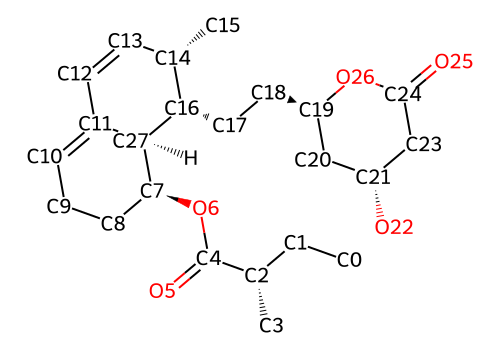

In [47]:
def draw_molecule_with_atom_indices(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", f"{atom.GetSymbol()}{atom.GetIdx()}")
    
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 350)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    
    display(SVG(drawer.GetDrawingText()))


draw_molecule_with_atom_indices(smiles)

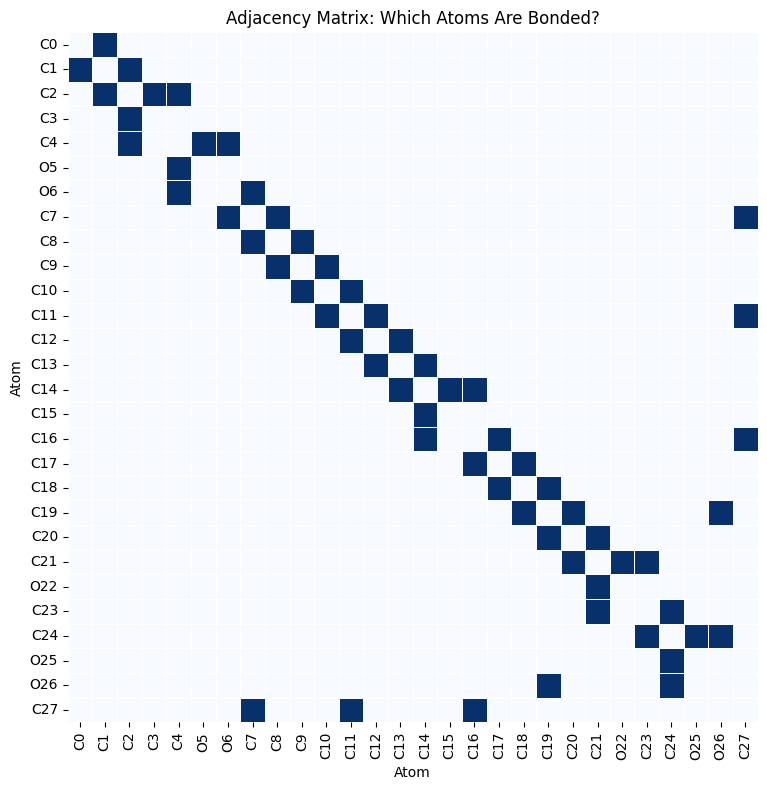

,C0,C1,C2,C3,C4,O5,O6,C7,C8,C9,...,C18,C19,C20,C21,O22,C23,C24,O25,O26,C27
C0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C4,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
C8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
def plot_adjacency_matrix(smiles):
    mol = Chem.MolFromSmiles(smiles)
    n_atoms = mol.GetNumAtoms()
    
    adjacency = np.zeros((n_atoms, n_atoms))
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        adjacency[i, j] = 1
        adjacency[j, i] = 1
    
    atom_labels = [
        f"{atom.GetSymbol()}{atom.GetIdx()}"
        for atom in mol.GetAtoms()
    ]
    
    plt.figure(figsize=(8,8))
    sns.heatmap(
        adjacency,
        cmap="Blues",
        square=True,
        xticklabels=atom_labels,
        yticklabels=atom_labels,
        cbar=False,
        linewidths=0.5
    )
    plt.title("Adjacency Matrix: Which Atoms Are Bonded?")
    plt.xlabel("Atom")
    plt.ylabel("Atom")
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(adjacency, index=atom_labels, columns=atom_labels)


adjacency_df = plot_adjacency_matrix(smiles)
adjacency_df

Row index: 0
SMILES: CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](CC[C@@H]3C[C@@H](O)CC(=O)O3)[C@H]21
BBB label: 1


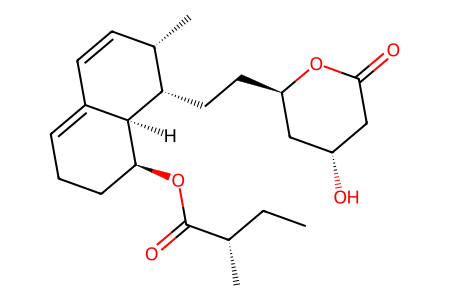

,Feature,Value
0,Molecular Weight,390.52000
1,LogP,3.94950
2,TPSA,72.83000
3,H-Bond Donors,1.00000
4,H-Bond Acceptors,5.00000
5,Rotatable Bonds,6.00000
6,Rings,3.00000
7,Aromatic Rings,0.00000
8,Heavy Atoms,28.00000
9,Heteroatoms,5.00000


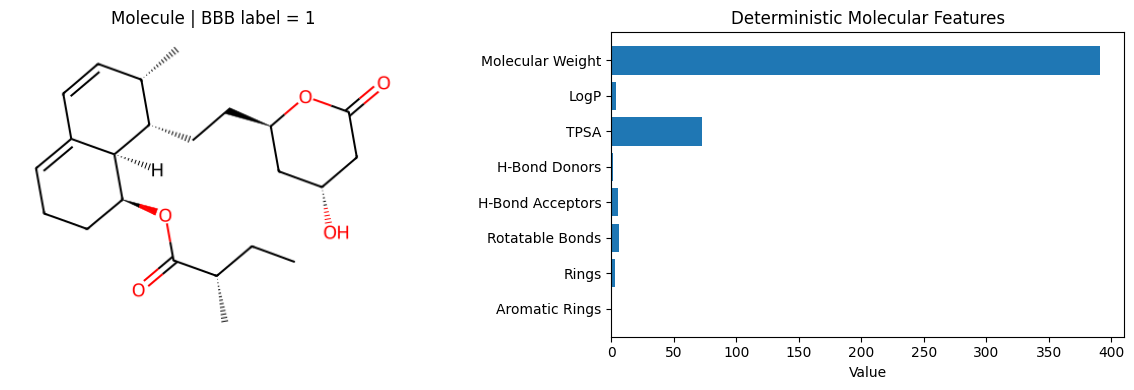

In [ ]:
def full_molecule_explainer(df, mol_index, smiles_col="Drug", label_col="Y"):
    smiles = df.iloc[mol_index][smiles_col]
    label = int(df.iloc[mol_index][label_col])
    mol = Chem.MolFromSmiles(smiles)
    features = calculate_molecule_features(smiles)
    
    print("=" * 80)
    print(f"Row index: {mol_index}")
    print(f"SMILES: {smiles}")
    print(f"BBB label: {label}")
    print("=" * 80)
    
    display(Draw.MolToImage(mol, size=(450, 300)))
    
    feature_table = pd.DataFrame(features.items(), columns=["Feature", "Value"])
    display(feature_table)
    
    molecule_card(smiles, label)
    plot_bbb_feature_guide(smiles)
    draw_molecule_with_atom_indices(smiles)
    plot_adjacency_matrix(smiles)


# Try changing the molecule index to explore a different example
full_molecule_explainer(df, mol_index=0)

##### Why look at deterministic molecular features?

Possibly before using a graph neural network, it is helpful to inspect features that are easy to compute and easy to understand.

Examples:

- **Molecular weight**: larger molecules may have more difficulty crossing biological barriers.
- **LogP**: measures hydrophobicity/lipophilicity. BBB penetration often favors moderate lipophilicity.
- **TPSA**: topological polar surface area. Highly polar molecules often cross membranes less easily.
- **H-bond donors and acceptors**: more hydrogen bonding often means stronger interaction with water, which can reduce passive membrane permeability.
- **Rotatable bonds**: flexible molecules may pay a larger entropy penalty when binding or crossing membranes.
- **Rings and aromatic rings**: affect shape, rigidity, and lipophilicity.

A simple model such as logistic regression can use these fixed features directly.

A GNN takes a different approach. It starts with atoms and bonds, then learns molecular representations by passing messages along the graph.

Check out [Therapeutics Data Commons (TDC)](https://tdcommons.ai/single_pred_tasks/overview/) to find other datasets for single-instance predictions. There are a variety of scenarios and objectives to explore.